In [16]:
import numpy as np
import pandas as pd
import os

class_path = []
file_path = []

for class_name in os.listdir(os.path.join("ISL_Dataset/custom_images")):
    for file_name in os.listdir(os.path.join("ISL_Dataset/custom_images", class_name)):
        file_path.append(os.path.join("ISL_Dataset", class_name, file_name))
        class_path.append(class_name)
df = pd.DataFrame(data={"class_path": class_path, "file_path": file_path})

In [17]:
df.head()

,class_path,file_path
0,0,ISL_Dataset\0\0_0.jpg
1,0,ISL_Dataset\0\0_1.jpg
2,0,ISL_Dataset\0\0_10.jpg
3,0,ISL_Dataset\0\0_100.jpg
4,0,ISL_Dataset\0\0_1000.jpg


C:\Users\super\AppData\Local\Temp\ipykernel_20716\2684734047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  seaborn.countplot(df['class_path'],palette="husl")


<Axes: title={'center': 'Class Distribution'}, xlabel='count', ylabel='class_path'>

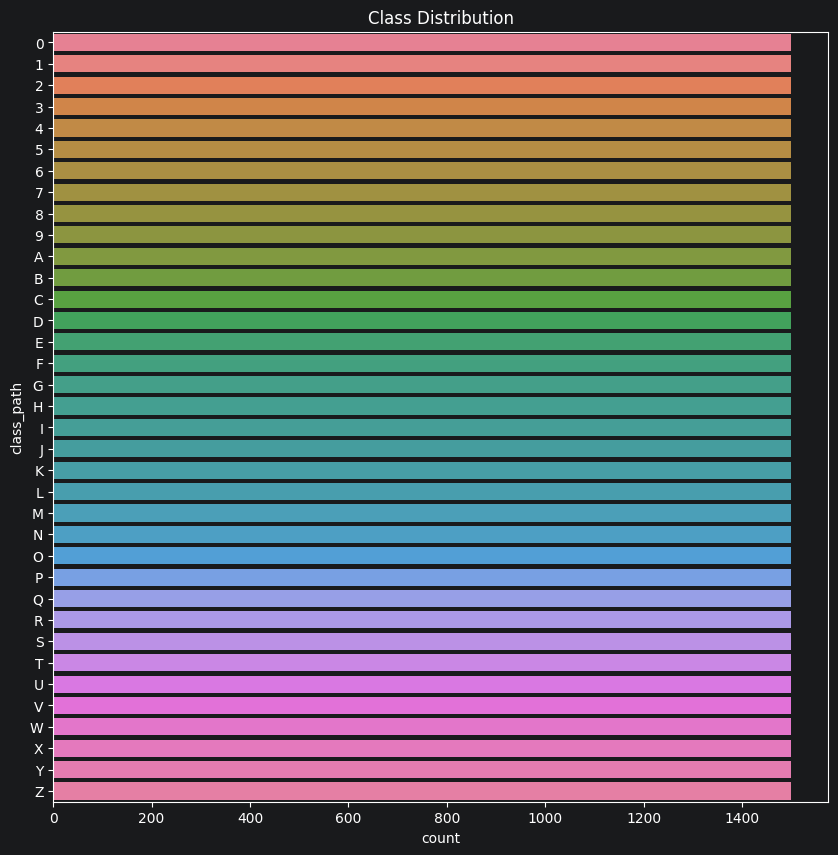

In [18]:
import matplotlib.pyplot as plt
import seaborn
plt.figure(figsize=(10,10))
plt.title("Class Distribution")
seaborn.countplot(df['class_path'],palette="husl")

In [19]:
df.to_csv("image_paths.csv", index=False, sep=",")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

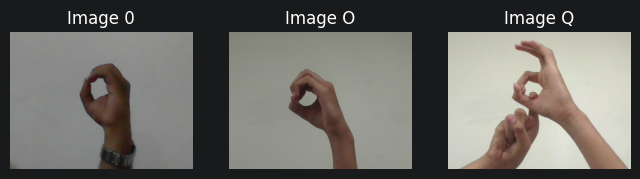

In [20]:
import cv2
import matplotlib.pyplot as plt

image_0 = cv2.imread("ISL_Dataset/custom_images/0/0_0.jpg")
image_O = cv2.imread("ISL_Dataset/custom_images/O/O_0.jpg")
image_Q = cv2.imread("ISL_Dataset/custom_images/Q/Q_0.jpg")

image_0 = cv2.cvtColor(image_0, cv2.COLOR_BGR2RGB)
image_O = cv2.cvtColor(image_O, cv2.COLOR_BGR2RGB)
image_Q = cv2.cvtColor(image_Q, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q, cmap="gray")
plt.title("Image Q")
plt.axis("off")


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

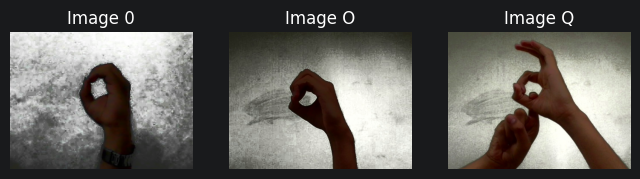

In [21]:
image_0_yuv = cv2.cvtColor(image_0, cv2.COLOR_BGR2YUV)
image_O_yuv = cv2.cvtColor(image_O, cv2.COLOR_BGR2YUV)
image_Q_yuv = cv2.cvtColor(image_Q, cv2.COLOR_BGR2YUV)

image_0_yuv[:,:,0] = cv2.equalizeHist(image_0_yuv[:,:,0])
image_O_yuv[:,:,0] = cv2.equalizeHist(image_O_yuv[:,:,0])
image_Q_yuv[:,:,0] = cv2.equalizeHist(image_Q_yuv[:,:,0])

image_0_enhanced = cv2.cvtColor(image_0_yuv, cv2.COLOR_YUV2BGR)
image_O_enhanced = cv2.cvtColor(image_O_yuv, cv2.COLOR_YUV2BGR)
image_Q_enhanced = cv2.cvtColor(image_Q_yuv, cv2.COLOR_YUV2BGR)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_enhanced, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_enhanced, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_enhanced, cmap="gray")
plt.title("Image Q")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

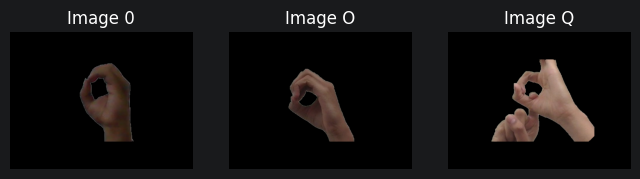

In [22]:

def remove_background(image, margin_pct=0.2):
    h, w = image.shape[:2]
    margin_x = int(margin_pct * w)
    margin_y = int(margin_pct * h)
    rect = (margin_x, margin_y, w - 2*margin_x, h - 2*margin_y)

    mask = np.zeros((h, w), np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 8, cv2.GC_INIT_WITH_RECT)

    # 0 and 2 = background, 1 and 3 = foreground -> collapse to binary 0/1
    binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

    result = image * binary_mask[:, :, np.newaxis]
    return result

image_0_nobg = remove_background(image_0)
image_O_nobg = remove_background(image_O)
image_Q_nobg = remove_background(image_Q)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_nobg)
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_nobg)
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_nobg)
plt.title("Image Q")
plt.axis("off")


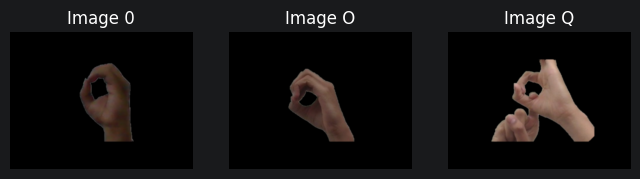

In [23]:
blurred_0 = cv2.GaussianBlur(image_0_nobg, (5,5), 0)
blurred_O = cv2.GaussianBlur(image_O_nobg, (5,5), 0)
blurred_Q = cv2.GaussianBlur(image_Q_nobg, (5,5), 0)

plt.figure(figsize=(8,4))
plt.subplot(1,3,1); plt.imshow(blurred_0); plt.title("Image 0"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(blurred_O); plt.title("Image O"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(blurred_Q); plt.title("Image Q"); plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

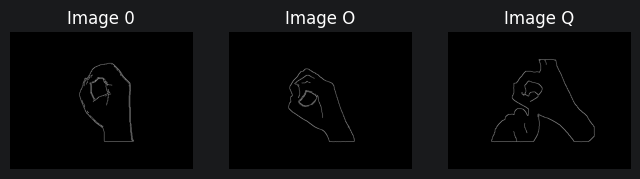

In [24]:
binary_mask_0 = np.any(image_0_nobg != 0, axis=2).astype("uint8")
binary_mask_O = np.any(image_O_nobg != 0, axis=2).astype("uint8")
binary_mask_Q = np.any(image_Q_nobg != 0, axis=2).astype("uint8")

foreground_pixels_0 = blurred_0[binary_mask_0 == 1]
foreground_pixels_O = blurred_O[binary_mask_O == 1]
foreground_pixels_Q = blurred_Q[binary_mask_Q == 1]

median_intensity_0 = np.median(foreground_pixels_0)
median_intensity_O = np.median(foreground_pixels_O)
median_intensity_Q = np.median(foreground_pixels_Q)

lower_threshold_0 = int(max(0, (1.0 - 0.33) * median_intensity_0))
upper_threshold_0 = int(min(255, (1.0 + 0.33) * median_intensity_0))
lower_threshold_O = int(max(0, (1.0 - 0.33) * median_intensity_O))
upper_threshold_O = int(min(255, (1.0 + 0.33) * median_intensity_O))
lower_threshold_Q = int(max(0, (1.0 - 0.33) * median_intensity_Q))
upper_threshold_Q = int(min(255, (1.0 + 0.33) * median_intensity_Q))

#Apply Canny
image_canny_0 = cv2.Canny(blurred_0, lower_threshold_0, upper_threshold_0)
image_canny_O = cv2.Canny(blurred_O, lower_threshold_O, upper_threshold_O)
image_canny_Q = cv2.Canny(blurred_Q, lower_threshold_Q, upper_threshold_Q)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_canny_0, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_canny_O, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_canny_Q, cmap="gray")
plt.title("Image Q")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

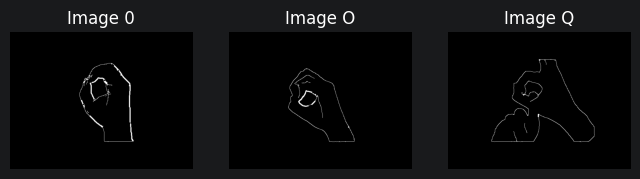

In [25]:
# Define a kernel (shape and size matter)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# Apply morphological operations on Canny edges
image_0_clean = cv2.morphologyEx(image_canny_0, cv2.MORPH_CLOSE, kernel)
image_O_clean = cv2.morphologyEx(image_canny_O, cv2.MORPH_CLOSE, kernel)
image_Q_clean = cv2.morphologyEx(image_canny_Q, cv2.MORPH_CLOSE, kernel)

# Optional: also try MORPH_OPEN to remove small specks
# image_0_clean = cv2.morphologyEx(image_canny_0, cv2.MORPH_OPEN, kernel)


plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_clean, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_clean, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_clean, cmap="gray")
plt.title("Image Q")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

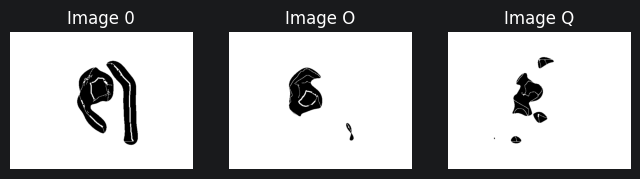

In [26]:
max_output_value = 255
neighbour_size = 99
subtract_from_mean = 10

image_0_binarized = cv2.adaptiveThreshold(image_0_clean, max_output_value, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, neighbour_size, subtract_from_mean)
image_O_binarized = cv2.adaptiveThreshold(image_O_clean, max_output_value, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, neighbour_size, subtract_from_mean)
image_Q_binarized = cv2.adaptiveThreshold(image_Q_clean, max_output_value, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, neighbour_size, subtract_from_mean)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_binarized, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_binarized, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_binarized, cmap="gray")
plt.title("Image Q")
plt.axis("off")

In [27]:
import urllib.request
url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
urllib.request.urlretrieve(url, "hand_landmarker.task")

('hand_landmarker.task', <http.client.HTTPMessage at 0x28e18e00190>)

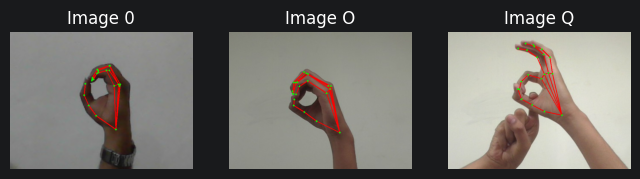

In [29]:
import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2
)
landmarker = HandLandmarker.create_from_options(options)

def detect_landmarks(image):
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
    result = landmarker.detect(mp_image)
    return result

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),          # thumb
    (0,5),(5,6),(6,7),(7,8),          # index finger
    (0,9),(9,10),(10,11),(11,12),     # middle finger
    (0,13),(13,14),(14,15),(15,16),   # ring finger
    (0,17),(17,18),(18,19),(19,20),   # pinky
    (5,9),(9,13),(13,17)              # palm/knuckle connections
]

def draw_landmarks(image, result):
    h, w = image.shape[:2]
    annotated = image.copy()

    for hand_landmarks in result.hand_landmarks:
        # draw connecting lines first, so dots sit on top
        for start_idx, end_idx in HAND_CONNECTIONS:
            start = hand_landmarks[start_idx]
            end = hand_landmarks[end_idx]
            x1, y1 = int(start.x * w), int(start.y * h)
            x2, y2 = int(end.x * w), int(end.y * h)
            cv2.line(annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # draw the landmark points
        for lm in hand_landmarks:
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (x, y), 3, (0, 255, 0), -1)

    return annotated

result_0 = detect_landmarks(image_0)
result_O = detect_landmarks(image_O)
result_Q = detect_landmarks(image_Q)

annotated_0 = draw_landmarks(image_0, result_0)
annotated_O = draw_landmarks(image_O, result_O)
annotated_Q = draw_landmarks(image_Q, result_Q)

plt.figure(figsize=(8,4))
plt.subplot(1,3,1); plt.imshow(annotated_0); plt.title("Image 0"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(annotated_O); plt.title("Image O"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(annotated_Q); plt.title("Image Q"); plt.axis("off")
plt.show()